# Moondream Cloud API: Kids Costume Photo Demo

Moondream is a compact, open-source vision-language model (VLM) designed to be fast and efficient enough to run almost anywhere, from a local machine to a hosted cloud API. Despite its small size, it exposes grounded visual skills such as captioning, visual querying, object detection, pointing, and segmentation through one simple interface.

This notebook demonstrates **hosted inference** with the Moondream Cloud API on a single image of three children dressed up indoors.

We will cover all five Cloud skills:

- `query`
- `caption`
- `detect`
- `point`
- `segment`

Instead of using boring toy prompts, this notebook leans into what is interesting about the image: costumes, accessories, gesture, and precise localization.


## Plan

We will use the following kinds of prompts:

1. **Caption**: compare short, normal, and long descriptions
2. **Query**: ask for a left-to-right structured breakdown of the costumes
3. **Detect**: localize not just `person`, but also costume-specific objects like `fairy wings` and `tiara`
4. **Point**: find `raised hand` positions and the `superman logo`
5. **Segment**: turn a coarse `person` detection into a precise mask for just the rightmost child

The notebook reads the Moondream API key from `MOONDREAM_API_KEY`, so the file itself does not need to store secrets.


In [ ]:
# Install only what the notebook actually uses.
# Keeping dependencies minimal makes the notebook easier to rerun in class.
import importlib.util
import os
import subprocess
import sys

required = {
    "requests": "requests",
    "PIL": "pillow",
    "matplotlib": "matplotlib",
}

missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]

if missing:
    # Use the current kernel's Python so packages land in the active environment.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", ", ".join(missing))
else:
    print("Dependencies already available.")


Dependencies already available.


## Imports and Setup

The image is hosted on LearnOpenCV, and this notebook downloads it at runtime.
After downloading it, we convert it into a data URL for the Cloud API calls while still keeping a local in-memory copy for visualization.


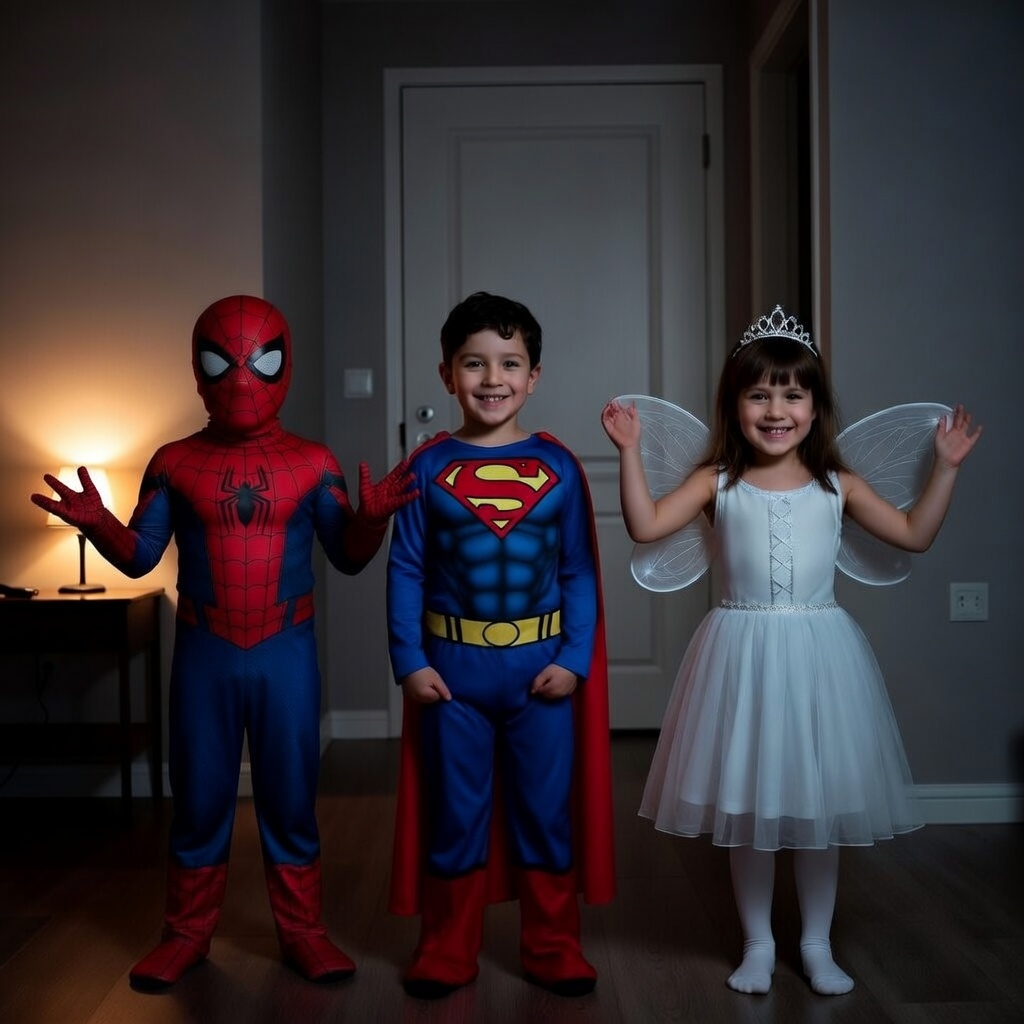

In [ ]:
# Standard-library helpers for encoding the image and pretty-printing results.
import base64
import json
import os
from html import escape
from io import BytesIO

# Third-party packages used for display and API calls.
import matplotlib.pyplot as plt
import requests
from IPython.display import HTML, SVG, display
from PIL import Image, ImageDraw

# Read the Cloud key from the environment so we do not hard-code secrets in the notebook.
#API_KEY = os.environ.get("MOONDREAM_API_KEY")
API_KEY = 'your_api_key_here'

if not API_KEY:
    raise RuntimeError("Set MOONDREAM_API_KEY before running this notebook.")

API_BASE = "https://api.moondream.ai/v1"
HOSTED_IMAGE_URL = "https://learnopencv.com/wp-content/uploads/2026/04/kids-1.jpeg"
HEADERS = {
    "Content-Type": "application/json",
    "X-Moondream-Auth": API_KEY,
}
DOWNLOAD_HEADERS = {
    # A browser-like user agent and referer help mirror a normal public fetch.
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36"
    ),
    "Referer": "https://learnopencv.com/",
}

# Download the demo image directly from LearnOpenCV so students can rerun the
# notebook without relying on a machine-specific local file.
image_response = requests.get(HOSTED_IMAGE_URL, headers=DOWNLOAD_HEADERS, timeout=120)
image_response.raise_for_status()
image = Image.open(BytesIO(image_response.content)).convert("RGB")

image


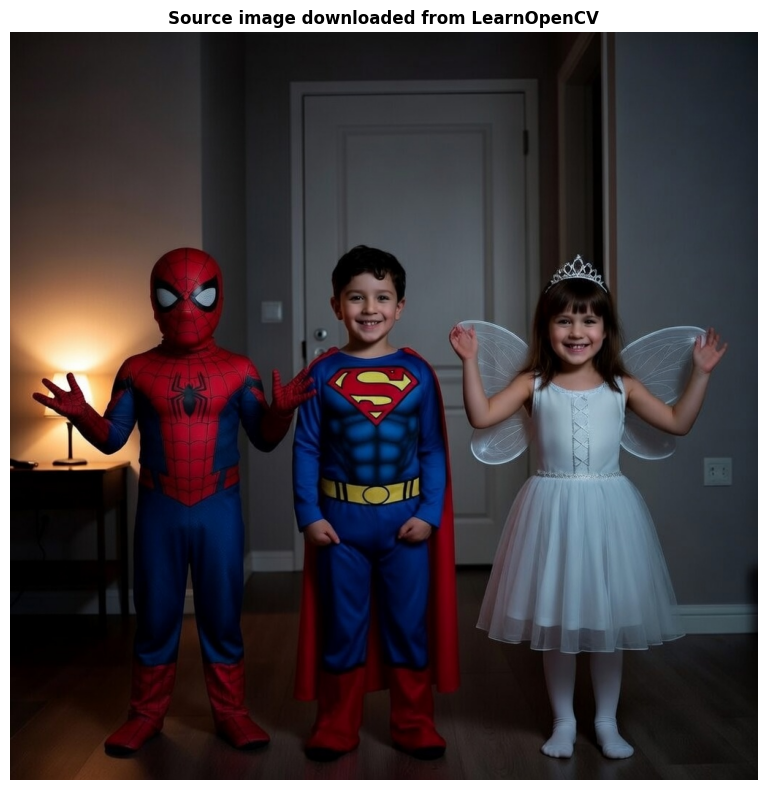

In [ ]:
def image_to_data_url(img: Image.Image, image_format: str = "JPEG") -> str:
    # Moondream Cloud accepts image URLs, and a data URL lets us send the image we
    # just downloaded from LearnOpenCV without relying on the API server being able
    # to fetch that third-party URL directly.
    buffer = BytesIO()
    img.save(buffer, format=image_format, quality=95)
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    return f"data:image/{image_format.lower()};base64,{encoded}"


API_IMAGE_URL = image_to_data_url(image)


def call_moondream(endpoint: str, payload: dict, timeout: int = 120) -> dict:
    # Thin wrapper around the Cloud API so the later cells stay focused on the idea,
    # not the request boilerplate.
    response = requests.post(
        f"{API_BASE}{endpoint}",
        headers=HEADERS,
        json=payload,
        timeout=timeout,
    )
    response.raise_for_status()
    return response.json()


def show(img: Image.Image, title: str = "", figsize=(8, 8)):
    # Simple Matplotlib image display helper used throughout the notebook.
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def draw_boxes(img: Image.Image, objects, color="red", width=4) -> Image.Image:
    # Convert normalized bbox coordinates from the API into pixel coordinates.
    annotated = img.copy()
    draw = ImageDraw.Draw(annotated)
    image_w, image_h = annotated.size

    for obj in objects:
        draw.rectangle(
            [
                obj["x_min"] * image_w,
                obj["y_min"] * image_h,
                obj["x_max"] * image_w,
                obj["y_max"] * image_h,
            ],
            outline=color,
            width=width,
        )
    return annotated


def draw_points(img: Image.Image, points, color="lime", radius=12) -> Image.Image:
    # Convert normalized point coordinates from the API into pixel coordinates.
    annotated = img.copy()
    draw = ImageDraw.Draw(annotated)
    image_w, image_h = annotated.size

    for point in points:
        cx = point["x"] * image_w
        cy = point["y"] * image_h
        draw.ellipse(
            (cx - radius, cy - radius, cx + radius, cy + radius),
            fill=color,
            outline="black",
            width=3,
        )
    return annotated


def show_segment_on_image(
    img: Image.Image,
    segment_result: dict,
    title: str = "",
    mask_fill: str = "rgba(0, 184, 148, 0.28)",
    mask_stroke: str = "#00c853",
):
    # The API returns an SVG path inside the returned bounding box.
    # Instead of showing the path separately, we embed the original image and the
    # transformed path into one SVG so students can see the mask directly on top
    # of the source photo.
    bbox = segment_result["bbox"]
    path = escape(segment_result["path"], quote=True)
    image_url = image_to_data_url(img, image_format="PNG")
    image_w, image_h = img.size
    left = bbox["x_min"] * image_w
    top = bbox["y_min"] * image_h
    width = (bbox["x_max"] - bbox["x_min"]) * image_w
    height = (bbox["y_max"] - bbox["y_min"]) * image_h
    title_html = (
        f'<div style="font-weight:700; margin:0 0 8px 0;">{escape(title)}</div>'
        if title
        else ""
    )

    svg = f'''
    <svg width="{image_w}" height="{image_h}" viewBox="0 0 {image_w} {image_h}" xmlns="http://www.w3.org/2000/svg">
      <image href="{image_url}" x="0" y="0" width="{image_w}" height="{image_h}" />
      <g transform="translate({left:.3f},{top:.3f}) scale({width:.3f},{height:.3f})">
        <path d="{path}" fill="{mask_fill}" stroke="none" />
        <path
          d="{path}"
          fill="none"
          stroke="{mask_stroke}"
          stroke-width="4"
          vector-effect="non-scaling-stroke"
          stroke-linejoin="round"
          stroke-linecap="round"
        />
      </g>
    </svg>
    '''
    if title_html:
        display(HTML(title_html))
    display(SVG(svg))


def print_metrics(result: dict):
    # The API includes useful timing metadata, so we surface it for discussion.
    metrics = result.get("metrics")
    if metrics:
        print(json.dumps(metrics, indent=2))
    else:
        print("No metrics returned.")


show(image, "Source image downloaded from LearnOpenCV")


## Caption

Captioning is the gentlest way to probe the API. Instead of asking a single caption question, we compare the built-in `short`, `normal`, and `long` styles to see how the model changes density and detail.


In [ ]:
caption_results = {}

# Ask for several caption lengths so students can see how one skill can support
# different downstream experiences, from alt text to richer narration.
for length in ["short", "normal", "long"]:
    result = call_moondream(
        "/caption",
        {
            "image_url": API_IMAGE_URL,
            "length": length,
            "stream": False,
        },
    )
    caption_results[length] = result
    print(f"\n[{length.upper()}]")
    print(result["caption"])

print("\nMetrics for the normal caption:")
print_metrics(caption_results["normal"])



[SHORT]
Three children in superhero costumes stand in a room: a boy in a Superman costume, a girl in a white fairy costume, and a boy in a Spider-Man costume.

[NORMAL]
Three children are dressed in superhero costumes: Spider-Man in a red and blue suit, Superman in a blue and red suit with a Superman "S" emblem, and a girl in a white fairy costume with a tiara. The background is a dimly lit room with a white door and a lamp.

[LONG]
In the center of the image, a young boy stands between two children dressed in superhero costumes. The boy is wearing a blue and red superhero suit with a prominent Superman logo on the chest. His dark hair is neatly styled, and he has a neutral expression. To his left, a child is dressed as Spider-Man, wearing a red and blue suit with a spider emblem on the chest. His arms are raised in a gesture, and his left hand is extended outward. To the right of the boy, a child is dressed as Wonder Woman, wearing a white dress adorned with silver details and a tiar

## Query

A generic question like “what is in this image?” would be too easy here. Instead, we ask for a **structured left-to-right costume breakdown** so the response has to combine reading order, costume recognition, pose, and expression.


In [ ]:
# A structured prompt makes the response easier to inspect and reuse.
query_prompt = (
    "Describe each child from left to right as JSON with keys "
    "costume_theme, standout_accessories, hand_pose, and smile."
)

query_result = call_moondream(
    "/query",
    {
        "image_url": API_IMAGE_URL,
        "question": query_prompt,
    },
)

print(query_result["answer"])

try:
    # If the model returns valid JSON, pretty-print it so the structure is clear.
    parsed_query = json.loads(query_result["answer"])
    print("\nParsed JSON:")
    print(json.dumps(parsed_query, indent=2))
except Exception:
    print("\nThe answer was not strict JSON, so it is shown as raw text.")

print("\nQuery metrics:")
print_metrics(query_result)


{
  "costume_theme": [
    "Spiderman",
    "Superman",
    "Angel"
  ],
  "standout_accessories": [
    "Spiderman: Red and blue web pattern, spider emblem",
    "Superman: Blue, red, and yellow suit with 'S' emblem",
    "Angel: White tiara, translucent wings"
  ],
  "hand_pose": [
    "Spiderman: Left hand raised, palm open",
    "Superman: Right hand raised, palm open",
    "Angel: Both hands raised, palms open"
  ],
  "smile": [
    "Spiderman: Wide smile, looking up",
    "Superman: Smiling, looking forward",
    "Angel: Smiling, looking up"
  ]
}

Parsed JSON:
{
  "costume_theme": [
    "Spiderman",
    "Superman",
    "Angel"
  ],
  "standout_accessories": [
    "Spiderman: Red and blue web pattern, spider emblem",
    "Superman: Blue, red, and yellow suit with 'S' emblem",
    "Angel: White tiara, translucent wings"
  ],
  "hand_pose": [
    "Spiderman: Left hand raised, palm open",
    "Superman: Right hand raised, palm open",
    "Angel: Both hands raised, palms open"
  ],
 

## Detect

`detect` gets more interesting when we go beyond `person`.

We will ask for:

- all `person` instances
- the `fairy wings`
- the `tiara`

That gives us both a broad scene-level localization and a costume-specific one.


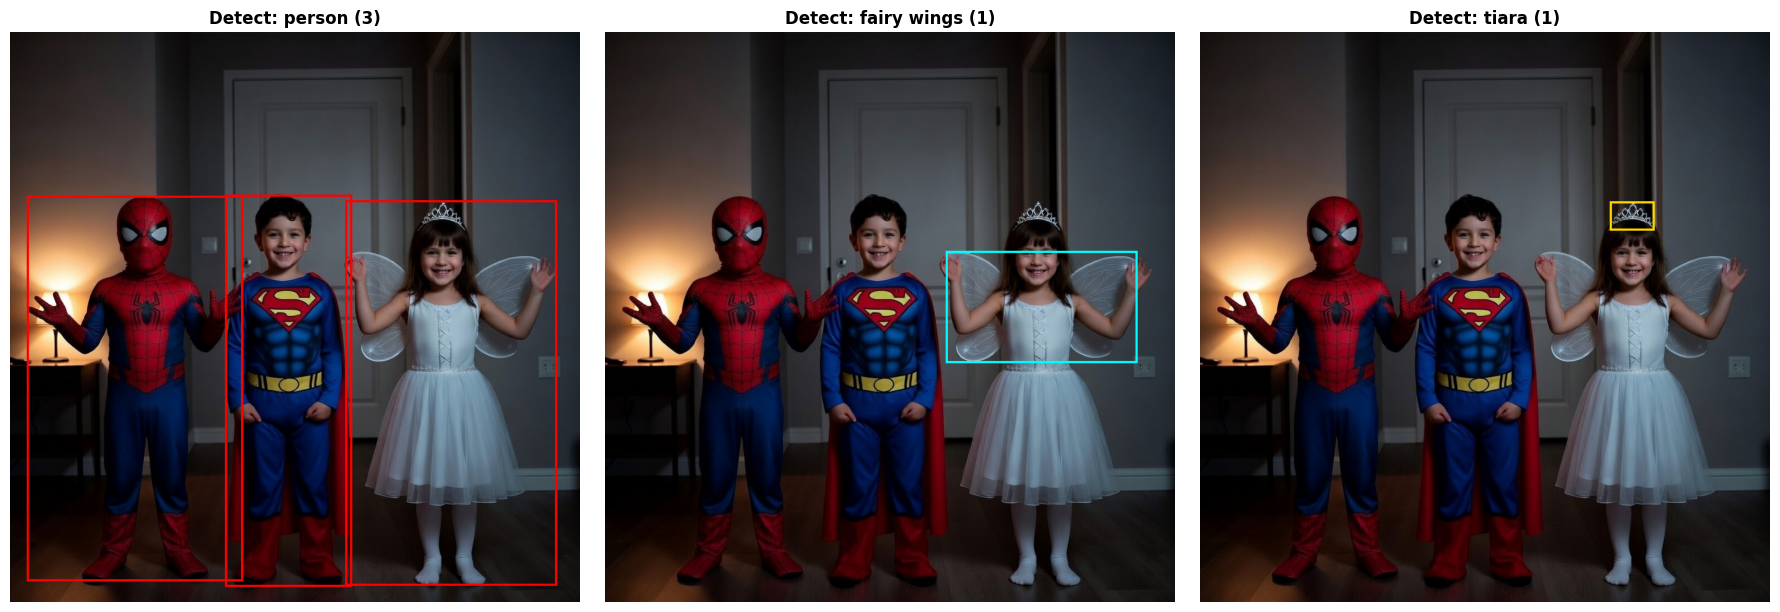

In [ ]:
# Run three detection prompts that operate at different scales:
# whole people, a medium accessory, and a very small accessory.
detect_people = call_moondream("/detect", {"image_url": API_IMAGE_URL, "object": "person"})
detect_wings = call_moondream("/detect", {"image_url": API_IMAGE_URL, "object": "fairy wings"})
detect_tiara = call_moondream("/detect", {"image_url": API_IMAGE_URL, "object": "tiara"})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(draw_boxes(image, detect_people["objects"], color="red"))
axes[0].set_title(f"Detect: person ({len(detect_people['objects'])})", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(draw_boxes(image, detect_wings["objects"], color="cyan"))
axes[1].set_title(f"Detect: fairy wings ({len(detect_wings['objects'])})", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(draw_boxes(image, detect_tiara["objects"], color="gold"))
axes[2].set_title(f"Detect: tiara ({len(detect_tiara['objects'])})", fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Point

`point` is a fun fit for fine details that are smaller than a full person box.

We will point to:

- every `raised hand`
- the `superman logo`

This gives us one many-instance pointing task and one tiny costume-detail task.


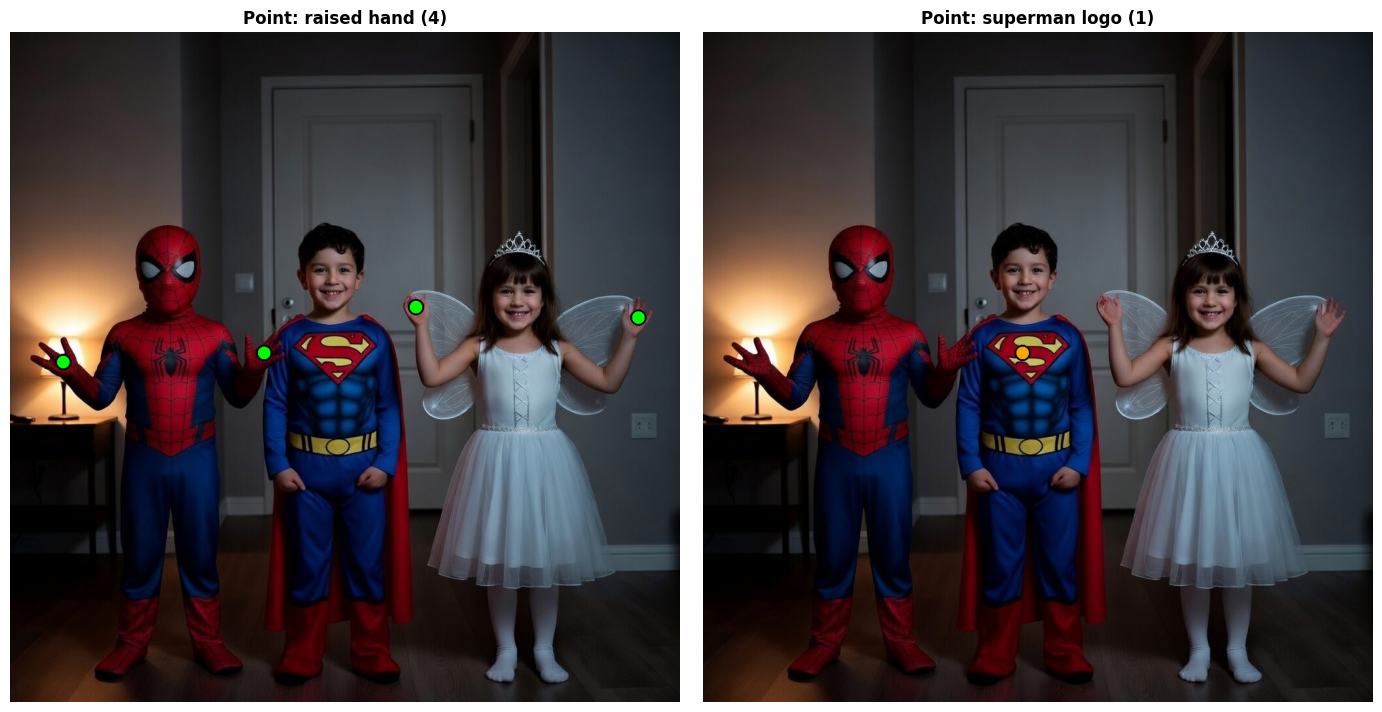

In [ ]:
# Pointing is a nice complement to detection when we care about one representative
# location instead of a full rectangle.
point_hands = call_moondream("/point", {"image_url": API_IMAGE_URL, "object": "raised hand"})
point_logo = call_moondream("/point", {"image_url": API_IMAGE_URL, "object": "superman logo"})

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(draw_points(image, point_hands["points"], color="lime"))
axes[0].set_title(f"Point: raised hand ({len(point_hands['points'])})", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(draw_points(image, point_logo["points"], color="orange"))
axes[1].set_title(f"Point: superman logo ({len(point_logo['points'])})", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Segment

Segmentation becomes much more useful when paired with another skill.

Here we:

1. reuse the earlier `person` detections
2. pick the **rightmost** detected child
3. feed that bounding box back into `segment`

That turns a coarse detection into a precise mask for just one subject.


Rightmost person box:
{
  "x_min": 0.587890625,
  "y_min": 0.294921875,
  "x_max": 0.958984375,
  "y_max": 0.970703125
}

Returned segment bbox:
{
  "x_min": 0.5869140625,
  "y_min": 0.302734375,
  "x_max": 0.958984375,
  "y_max": 0.97265625
}

SVG path prefix:
M.581,.998C.570,.996,.559,.989,.551,.980C.548,.977,.541,.971,.536,.967C.521,.955,.520,.952,.521,.934C.522,.914,.519,.887,.513,.877C.506,.862,.503,.825,.509,.808C.511,.801,.511,.799,.506,.795C.500,.789...


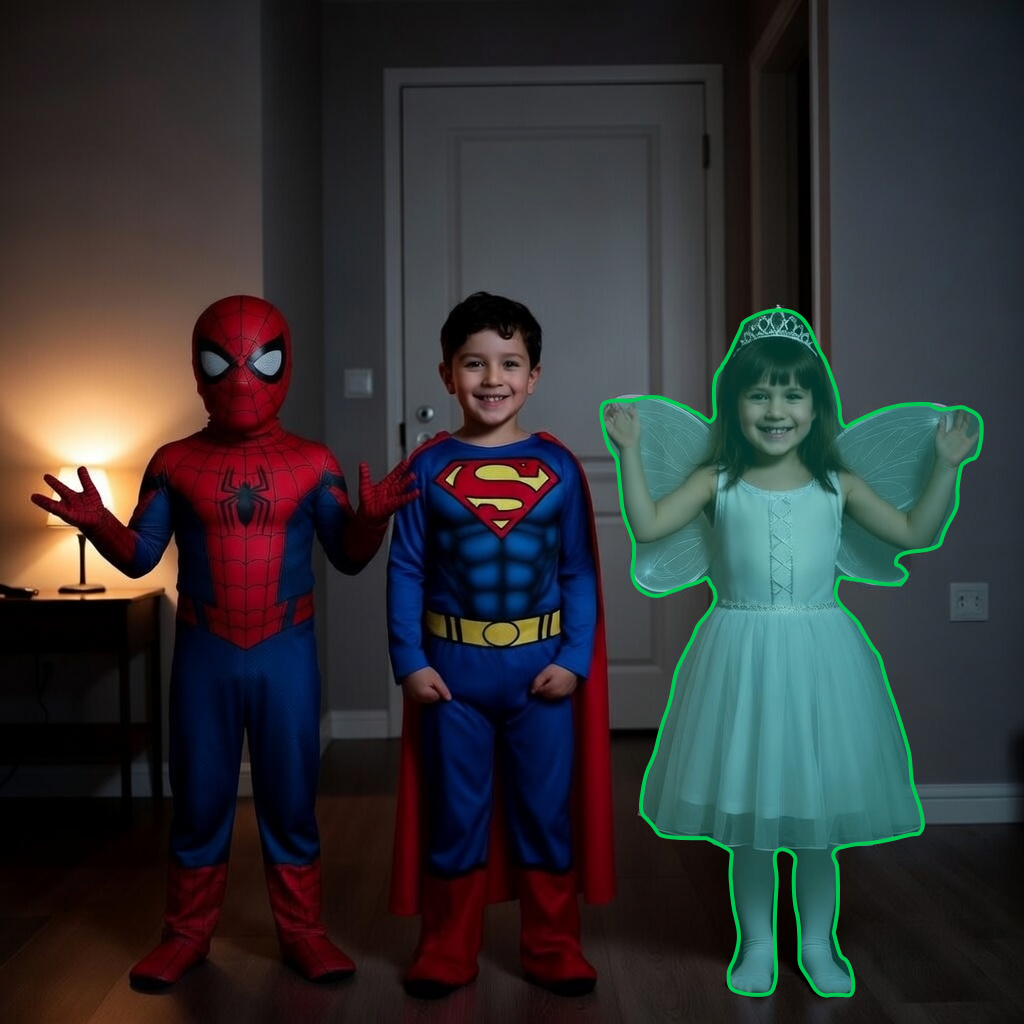

In [ ]:
# Reuse the earlier person detections instead of asking the model to rediscover the
# subject from scratch. This is a realistic pattern for multi-step vision systems.
rightmost_person = max(
    detect_people["objects"],
    key=lambda obj: (obj["x_min"] + obj["x_max"]) / 2,
)

segment_person = call_moondream(
    "/segment",
    {
        "image_url": API_IMAGE_URL,
        "object": "person",
        "spatial_refs": [[
            rightmost_person["x_min"],
            rightmost_person["y_min"],
            rightmost_person["x_max"],
            rightmost_person["y_max"],
        ]],
    },
)

print("Rightmost person box:")
print(json.dumps(rightmost_person, indent=2))
print("\nReturned segment bbox:")
print(json.dumps(segment_person["bbox"], indent=2))
print("\nSVG path prefix:")
print(segment_person["path"][:200] + "...")

# Draw the SVG mask directly on top of the original image so the segmentation
# result reads like a single visualization rather than a detached path string.
show_segment_on_image(image, segment_person, "Segmented rightmost child")


## Wrap-Up

On this single image, the Moondream Cloud API handled:

- natural-language captioning at multiple lengths
- structured scene understanding through `query`
- broad and fine-grained localization with `detect`
- precise keypoint-style placement with `point`
- mask-style object extraction with `segment`

The big pattern is that the same image can support very different product behaviors depending on which skill you call.
